In [ ]:
!pip install yfinance

In [ ]:
# Import packages needed

import matplotlib.pyplot as plt
import numpy as np  # when working with large numerical datasets and performing mathematical operations
import pandas as pd  # when dealing with structured/tabular data like CSVs, SQL tables, or time-series data
import yfinance as yf
from yfinance.exceptions import YFRateLimitError
from sklearn.metrics import mean_squared_error

import time

display("Practice exercise one")

'Practice exercise one'

In [3]:
display("Question 1: Download and plot Microsoft stock price, volume data since inception at varying frequency (daily, weekly, monthly)")

'Question 1: Download and plot Microsoft stock price, volume data since inception at varying frequency (daily, weekly, monthly)'

In [4]:
# Microsoft data
msft = yf.Ticker("MSFT")

In [5]:
msft

yfinance.Ticker object <MSFT>

In [6]:
# Print all attributes and methods
print(dir(msft))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_analysis', '_data', '_download_options', '_earnings', '_earnings_dates', '_expirations', '_fast_info', '_fetch_ticker_tz', '_financials', '_fundamentals', '_funds_data', '_get_earnings_dates_using_scrape', '_get_earnings_dates_using_screener', '_get_ticker_tz', '_holders', '_isin', '_lazy_load_price_history', '_message_handler', '_news', '_options2df', '_price_history', '_quote', '_shares', '_tz', '_underlying', 'actions', 'analyst_price_targets', 'balance_sheet', 'balancesheet', 'calendar', 'capital_gains', 'cash_flow', 'cashflow', 'dividends', 'earnings', 'earnings_dates', 'earnings_estimate', 'earnings_history', 'eps_revisions

In [7]:
msft.actions

,Dividends,Stock Splits
Date,,
1987-09-21 00:00:00-04:00,0.00,2.0
1990-04-16 00:00:00-04:00,0.00,2.0
1991-06-27 00:00:00-04:00,0.00,1.5
1992-06-15 00:00:00-04:00,0.00,1.5
1994-05-23 00:00:00-04:00,0.00,2.0
...,...,...
2024-11-21 00:00:00-05:00,0.83,0.0
2025-02-20 00:00:00-05:00,0.83,0.0
2025-05-15 00:00:00-04:00,0.83,0.0


In [8]:
msft.splits

Date
1987-09-21 00:00:00-04:00    2.0
1990-04-16 00:00:00-04:00    2.0
1991-06-27 00:00:00-04:00    1.5
1992-06-15 00:00:00-04:00    1.5
1994-05-23 00:00:00-04:00    2.0
1996-12-09 00:00:00-05:00    2.0
1998-02-23 00:00:00-05:00    2.0
1999-03-29 00:00:00-05:00    2.0
2003-02-18 00:00:00-05:00    2.0
Name: Stock Splits, dtype: float64

In [8]:
msft.info

{'address1': 'One Microsoft Way',
 'city': 'Redmond',
 'state': 'WA',
 'zip': '98052-6399',
 'country': 'United States',
 'phone': '425 882 8080',
 'website': 'https://www.microsoft.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer serv

In [9]:
tickers = yf.Tickers('msft aapl goog')

In [10]:
# tickers.tickers['AAPL'].history(period="3mo")
tickers.tickers['AAPL'].history(period='3mo')


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-11-14 00:00:00-05:00,270.796590,275.702003,269.347964,272.155334,47431300,0.00,0.0
2025-11-17 00:00:00-05:00,268.568705,270.237127,265.481598,267.209961,45018300,0.00,0.0
2025-11-18 00:00:00-05:00,269.737607,270.456935,265.071989,267.190002,45677300,0.00,0.0
2025-11-19 00:00:00-05:00,265.281763,271.955511,265.251793,268.308929,40424500,0.00,0.0
2025-11-20 00:00:00-05:00,270.576804,275.172509,265.671421,266.001099,45823600,0.00,0.0
...,...,...,...,...,...,...,...
2026-02-09 00:00:00-05:00,277.910004,278.200012,271.700012,274.619995,44623400,0.26,0.0
2026-02-10 00:00:00-05:00,274.890015,275.369995,272.940002,273.679993,34376900,0.00,0.0
2026-02-11 00:00:00-05:00,274.700012,280.179993,274.450012,275.500000,51931300,0.00,0.0


In [11]:
# Get Daily data
# data_d = yf.download('MSFT','2009-08-01','2020-08-01', interval = "1d")
data_d = yf.download('MSFT', start="1980-12-12", interval = "1d", auto_adjust=False)
# Convert to weekly
data_w = yf.download('MSFT', start="1980-12-12", interval = "1wk", auto_adjust=False)
# Convert to monthly
data_m = yf.download('MSFT', start="1980-12-12", interval = "1mo", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
data_m

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,
1986-03-01,0.058328,0.095486,0.103299,0.088542,0.088542,1857052800
1986-04-01,0.068403,0.111979,0.121962,0.092882,0.095486,547142400
1986-05-01,0.074236,0.121528,0.123264,0.107639,0.111979,333446400
1986-06-01,0.065222,0.106771,0.121528,0.102431,0.121528,293788800
1986-07-01,0.060449,0.098958,0.109375,0.090278,0.106771,460800000
...,...,...,...,...,...,...
2025-10-01,516.842651,517.809998,553.719971,506.000000,514.799988,468447000
2025-11-01,491.090881,492.010010,524.960022,464.890015,519.809998,479480700


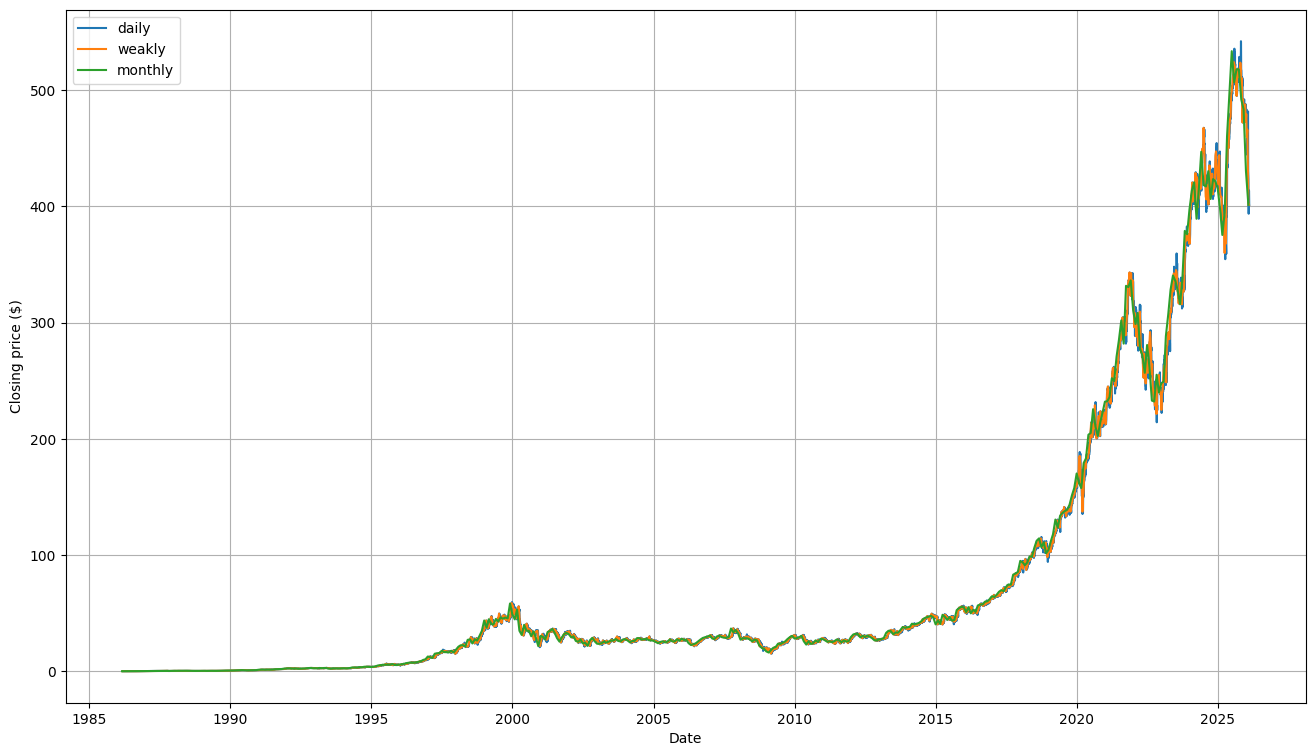

In [13]:
# Plot - Close
fig , ax = plt.subplots(figsize=(16,9))
ax.plot(data_d["Close"], label = "daily")
ax.plot(data_w["Close"], label = "weakly")
ax.plot(data_m["Close"], label = "monthly")
ax.set_xlabel('Date')
ax.set_ylabel('Closing price ($)')
ax.legend()
ax.grid()

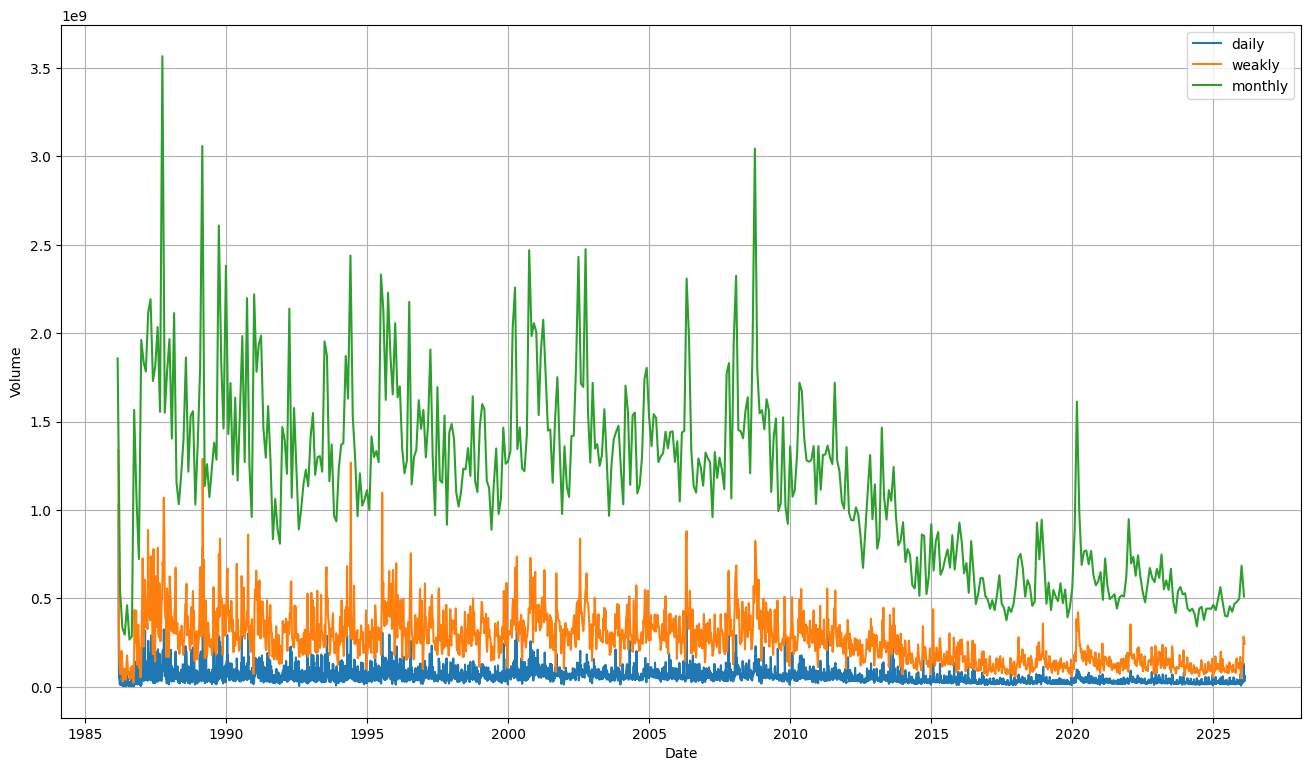

In [14]:
# Plot - Volume
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(data_d["Volume"], label = "daily")
ax.plot(data_w["Volume"], label = "weakly")
ax.plot(data_m["Volume"], label = "monthly")
ax.set_xlabel('Date')
ax.set_ylabel('Volume')
ax.legend()
ax.grid()

In [24]:
display("Question 2: What transformations should we perform on the data? Why?")

'Question 2: What transformations should we perform on the data? Why?'

In [ ]:
# Log transforming financial prices and volume stabilizes variance, converts multiplicative relationships into additive ones, and helps normalize heavily skewed, positive-only data.
# In finance, this approach handles compounding effects (returns) and compresses large-scale ranges, making models more accurate, linear, and effective at capturing relative changes. 

# Why Log Transform Prices & Volume in Finance:
#     1) Stability and Normalization: Financial data like prices and volume are typically positive, right-skewed, and exhibit increasing variance (heteroscedasticity) over time. Logs compress the scale of large outliers, reducing skewness and making the data better conform to normal distributions, which is essential for statistical modeling.
#     2) Multiplicative to Additive Conversion: Financial returns are compounding (multiplicative), not additive ($100 to $110 is a 10% gain, while $1000 to $1100 is also a 10% gain, despite a larger absolute value). 
         # Logs convert these multiplicative changes into additive changes, which are easier for linear models to handle.
#     3) Relative Changes vs. Absolute Changes: Logarithmic transformations allow for the interpretation of data in terms of percentages or relative changes rather than absolute dollar amounts. This is more relevant for comparing assets of different magnitudes.
#     4) Stabilizing Volatility: In time series analysis, log transformation reduces the impact of extreme values (high volatility), which helps in achieving a more constant variance (homoscedasticity) required for many econometric models. 

# Common Application:
#     Prices: Used to calculate log returns for better modeling of compounding growth.
#     Volume: Often log-transformed to stabilize variance and make extreme, high-volume days less disproportionately influential in regression models. 

In [15]:
# Compute Log returns
data_d['log_ret'] = np.log(data_d["Close"]) - np.log(data_d["Close"].shift(1))
data_w['log_ret'] = np.log(data_w["Close"]) - np.log(data_w["Close"].shift(1))
data_m['log_ret'] = np.log(data_m["Close"]) - np.log(data_m["Close"].shift(1))

In [16]:
data_m["Volume"][np.isfinite(data_m["Volume"])]

Ticker,MSFT
Date,
1986-03-01,1857052800
1986-04-01,547142400
1986-05-01,333446400
1986-06-01,293788800
1986-07-01,460800000
...,...
2025-10-01,468447000
2025-11-01,479480700
2025-12-01,496558500


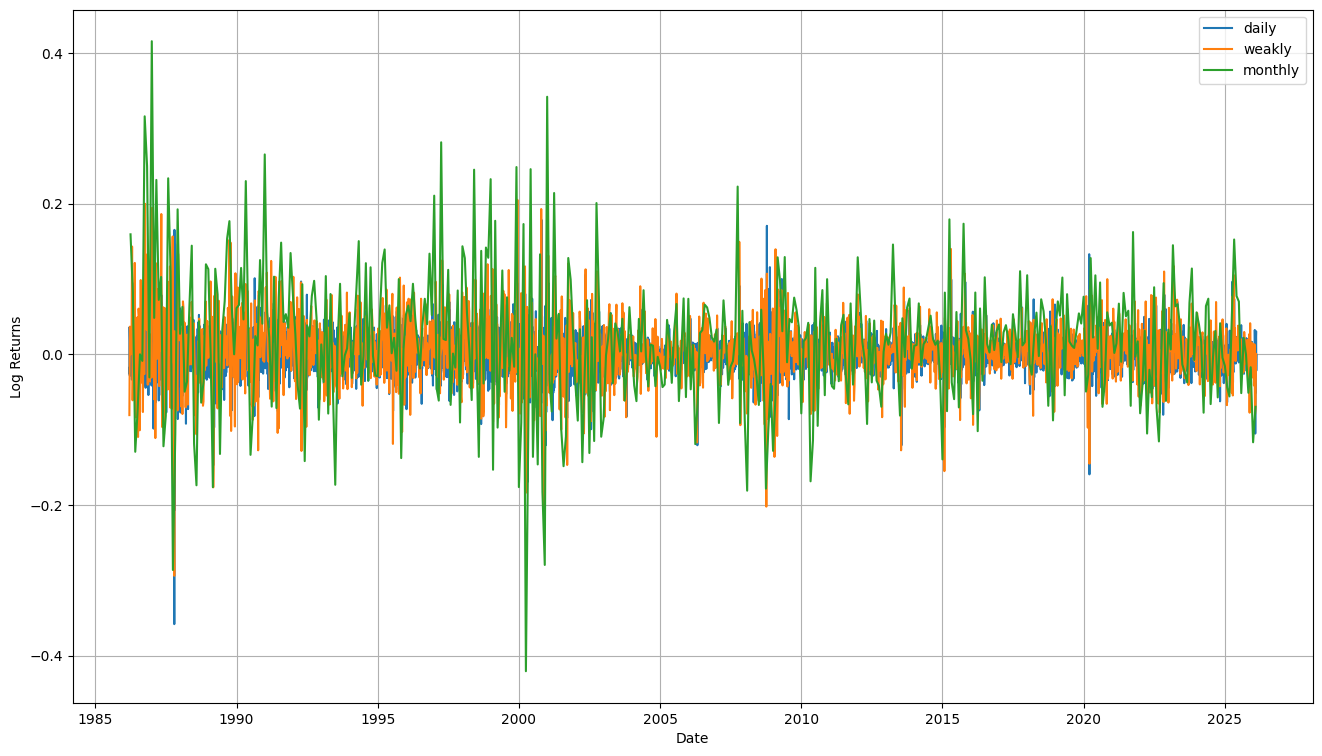

In [17]:
# Plot - Log returns
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(data_d["log_ret"], label = "daily")
ax.plot(data_w["log_ret"], label = "weakly")
ax.plot(data_m["log_ret"], label = "monthly")
ax.set_xlabel('Date')
ax.set_ylabel('Log Returns')
ax.legend()
ax.grid()

In [ ]:
data_m = data_m.dropna()

'Question 3: Find moments and discriptive stats'

kurt:  [0.75163006]
skew:  [0.62217514]
mean:  1162671206.4875
median:  1175241600.0


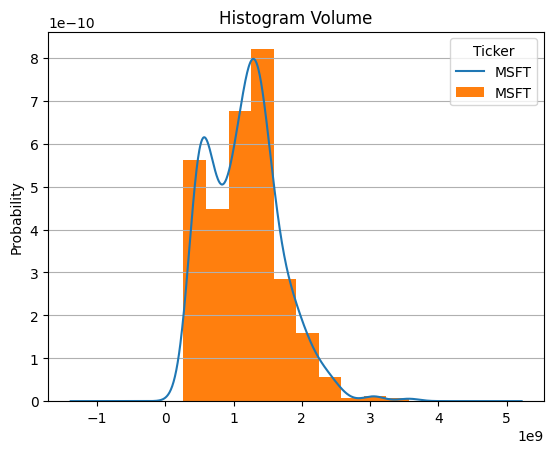

In [ ]:
display("Question 3: Find moments and discriptive stats")
# Do histogram volumes
dist = pd.DataFrame(data_m["Volume"])
dist.agg(['min', 'max', 'mean', 'std']).round(decimals=2)
fig, ax = plt.subplots()
dist.plot.kde(ax=ax, title='Histogram Volume')  # kernel (prob) density function
dist.plot.hist(density=True, ax=ax)  # explain
ax.set_ylabel('Probability')
ax.grid(axis='y')
# Kurtosis and Skewness
from scipy.stats import kurtosis
from scipy.stats import skew
print("kurt: ", kurtosis(data_m["Volume"][np.isfinite(data_m["Volume"])]))
print("skew: ", skew(data_m["Volume"][np.isfinite(data_m["Volume"])]))   # A positively skewed distribution has a long right tail and a large area below the curve toward the left
print("mean: ", np.average(data_m["Volume"][np.isfinite(data_m["Volume"])]))
print("median: ", np.median(data_m["Volume"][np.isfinite(data_m["Volume"])]))

In [ ]:
data_m

Price,Adj Close,Close,High,Low,Open,Volume,log_ret
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,
Date,,,,,,,
1986-04-01,0.068403,0.111979,0.121962,0.092882,0.095486,547142400,0.159332
1986-05-01,0.074236,0.121528,0.123264,0.107639,0.111979,333446400,0.081833
1986-06-01,0.065222,0.106771,0.121528,0.102431,0.121528,293788800,-0.129458
1986-07-01,0.060449,0.098958,0.109375,0.090278,0.106771,460800000,-0.075991
1986-08-01,0.060449,0.098958,0.106771,0.094618,0.098958,266256000,0.000000
...,...,...,...,...,...,...,...
2025-10-01,516.842651,517.809998,553.719971,506.000000,514.799988,468447000,-0.000270
2025-11-01,491.090881,492.010010,524.960022,464.890015,519.809998,479480700,-0.051109


In [ ]:
# params

In [ ]:
display("Question 4: Build an autoregressive model that expresses the price development as a function of past prices; what does the model tell us about the viability of building a momentum strategy?")
# Estimate AR(1) with drift

# Creates a numpy array of returns at each sampling frequency.
for j in range(3):
    if j == 0:
        x_t = np.asarray(data_m.log_ret)
        print('monthly')
    elif j == 1:
        x_t = np.asarray(data_w.log_ret)
        print('weekly')
    elif j == 2:
        x_t = np.asarray(data_d.log_ret)
        print('daily')
    x_t_1 = x_t[0:np.size(x_t,0)-1]     # FOR COMPATIBILITY, WHEN WE CONSIDER A LAG VARIABLE
    x_t = x_t[1:np.size(x_t,0)]         # FOR COMPATIBILITY, WHEN WE CONSIDER A LAG VARIABLE
    nans = x_t_1*x_t                    # IDENTIFY NANs
    RHS = np.c_[np.ones_like(x_t)[np.isfinite(nans)], x_t_1[np.isfinite(nans)]]  # CONCATENATES ARRAYS -> CONSTANT WITH THE REGRESSOR
    params = np.linalg.pinv(RHS.T@RHS)@(RHS.T@x_t[np.isfinite(nans)])  # (XX^T)^{-1}X^TY
    y_hat = RHS@params
    MSE = mean_squared_error(y_hat,x_t[np.isfinite(nans)])   # variance of the error term
    params_std = MSE*np.linalg.pinv(RHS.T@RHS)               # standard errors
    # Standard deviation refers to the true (but unknown) variability.
    # Standard error is our estimated standard deviation, using MSE instead of the true sigma^2
    params_std = [np.sqrt(params_std[0,0]), np.sqrt(params_std[1,1])]  # square roots of diagonals -> Calculate variance of OLS estimate
    print('params')
    print(params)
    print('standard errors')
    print(params_std)
    print('t-stat')
    print(params/params_std)  # negative and weakly significant relationship (for daily) -> problems?
    # Newey-West - >In other words, we are assuming independent and homoskedastic errors.

'Question 4: Build an autoregressive model that expresses the price development as a function of past prices; what does the model tell us about the viability of building a momentum strategy?'

monthly
params
[ 0.01812118 -0.0567823 ]
standard errors
[0.004200017315206055, 0.04559137768378952]
t-stat
[ 4.31454981 -1.24546141]
weekly
params
[ 0.00422215 -0.05058366]
standard errors
[0.0009485544596364849, 0.021867595097074224]
t-stat
[ 4.45114427 -2.31317871]
daily
params
[ 0.00083815 -0.01667678]
standard errors
[0.00020959273036791443, 0.009968920648109045]
t-stat
[ 3.9989545  -1.67287693]


In [35]:
type(params)

numpy.ndarray